In [ ]:
# Slide 1
# Image Data
# https://www.imageprocessingplace.com/DIP-3E/dip3e_book_images_downloads.htm

import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_comparison(img_orig, img_trans, title_trans):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(img_orig, cmap='gray', vmin=0, vmax=255)
    plt.title(f"Original {img_orig.shape}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(img_trans, cmap='gray', vmin=0, vmax=255)
    plt.title(f"{title_trans} {img_trans.shape}")
    plt.axis('off')
    plt.show()

Shrinking by Replacement

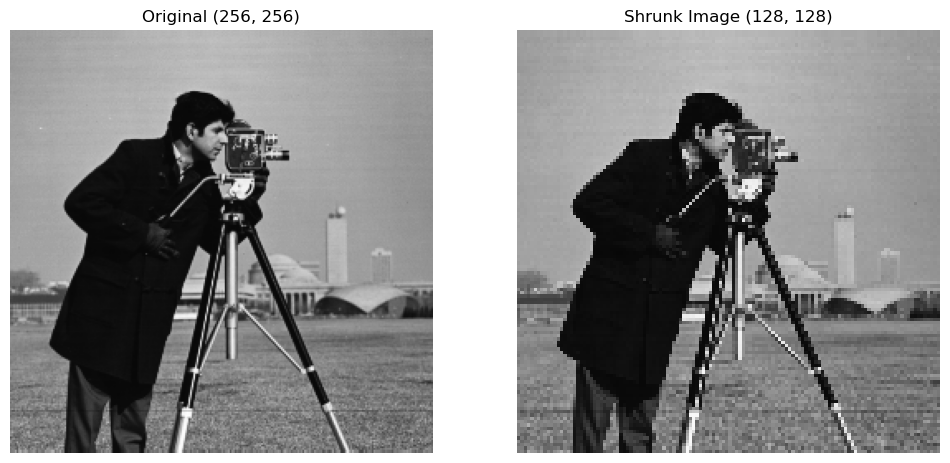

In [ ]:
#1.1 Shrink image by selecting every 2nd pixel (Row and Column) manually

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

factor = 2
H, W = img.shape
# Create empty array of half size
shrunk_img = np.zeros((H // factor, W // factor), dtype=np.uint8)

for i in range(0, H, factor):
    for j in range(0, W, factor):
        shrunk_img[i // factor, j // factor] = img[i, j]

show_comparison(img, shrunk_img, "Shrunk Image")

Zooming by Replication

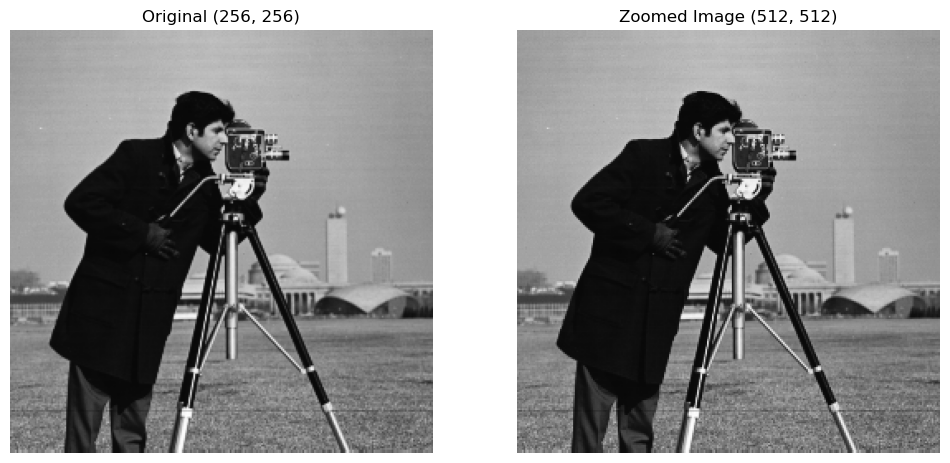

In [ ]:
#1.2 Zoom image by 2x using Nearest Neighbor replication (copying pixels)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

factor = 2
H, W = img.shape
zoomed_img = np.zeros((H * factor, W * factor), dtype=np.uint8)

for i in range(H * factor):
    for j in range(W * factor):
        # Map output coordinate back to input coordinate
        zoomed_img[i, j] = img[i // factor, j // factor]

show_comparison(img, zoomed_img, "Zoomed Image")

Decreasing Spatial Resolution

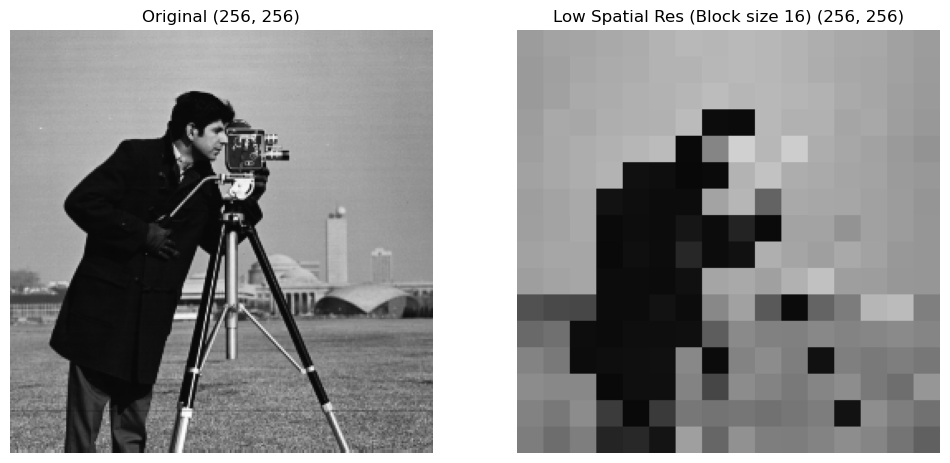

In [ ]:
#1.3 Simulate low spatial resolution by skipping pixels (downsampling) then replicating back to original size

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

step = 16  # Keep only 1 pixel every 16 pixels
H, W = img.shape
low_spatial = np.zeros((H, W), dtype=np.uint8)

for i in range(H):
    for j in range(W):
        # Sample the pixel from the "block" start
        r_idx = (i // step) * step
        c_idx = (j // step) * step
        # Handle edge cases
        r_idx = min(r_idx, H - 1)
        c_idx = min(c_idx, W - 1)
        low_spatial[i, j] = img[r_idx, c_idx]

show_comparison(img, low_spatial, f"Low Spatial Res (Block size {step})")

Decreasing Intensity Resolution

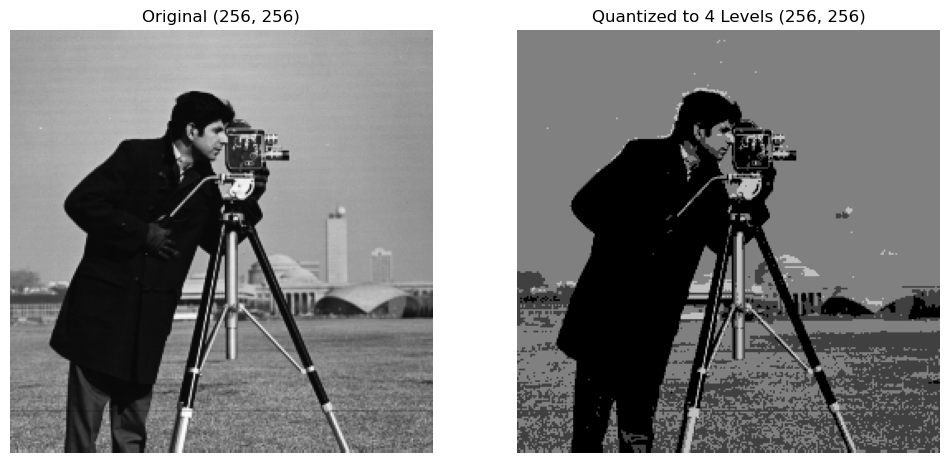

In [ ]:
#1.4 Reduce intensity from 256 levels (8-bit) to 4 levels (2-bit)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

target_levels = 4
# Calculate the size of each bin (256 / 4 = 64)
bin_size = 256 // target_levels
low_intensity = np.zeros_like(img)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        # Integer division drops the detail, multiplying brings it back to 0-255 scale
        pixel_val = img[i, j]
        low_intensity[i, j] = (pixel_val // bin_size) * bin_size

show_comparison(img, low_intensity, f"Quantized to {target_levels} Levels")

Cropping

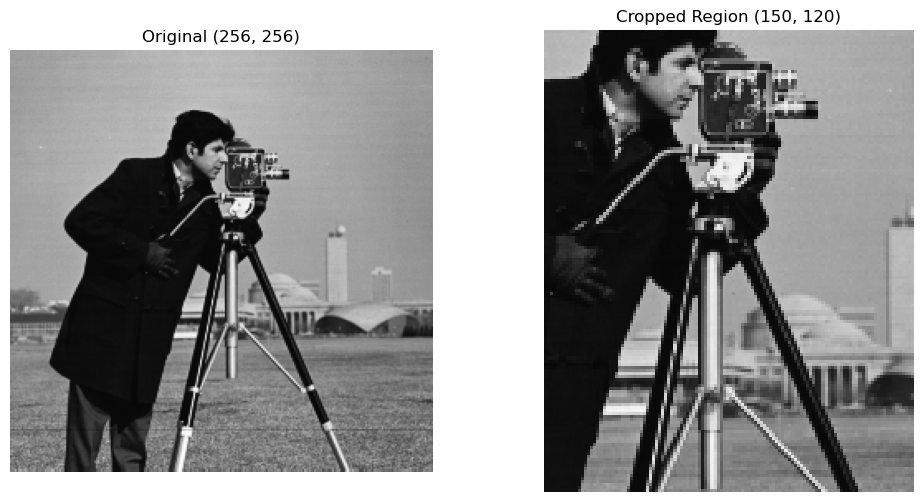

In [ ]:
#1.5 Crop a specific region (Rows 50 to 200, Columns 80 to 200)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

y1, y2 = 50, 200
x1, x2 = 80, 200
H_crop = y2 - y1
W_crop = x2 - x1
cropped_img = np.zeros((H_crop, W_crop), dtype=np.uint8)

for i in range(H_crop):
    for j in range(W_crop):
        cropped_img[i, j] = img[y1 + i, x1 + j]

show_comparison(img, cropped_img, "Cropped Region")

Mirroring

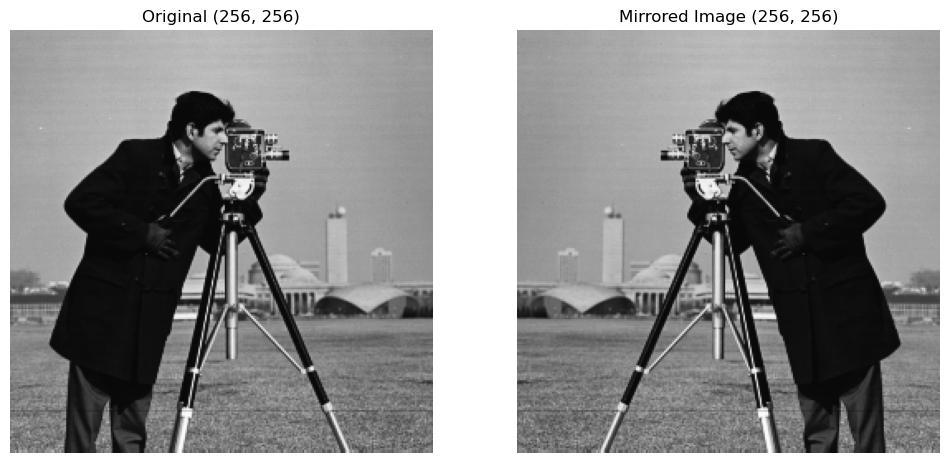

In [ ]:
#1.6.1 Mirror the image horizontally (flip columns)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

H, W = img.shape
mirrored_img = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        # Copy pixel from the opposite side of the row
        mirrored_img[i, j] = img[i, W - 1 - j]

show_comparison(img, mirrored_img, "Mirrored Image")

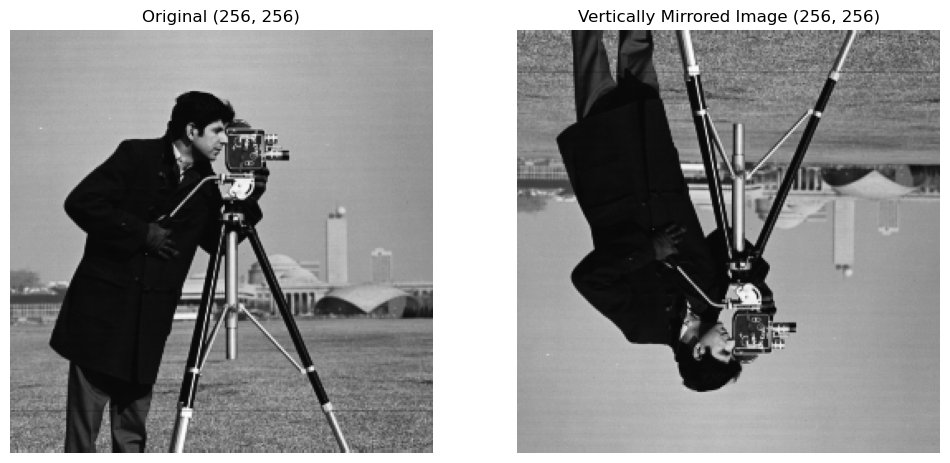

In [ ]:
#1.6.2 Mirror the image vertically (flip rows)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

H, W = img.shape
mirrored_img = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        # Copy pixel from the opposite side of the column (flip rows)
        mirrored_img[i, j] = img[H - 1 - i, j]

show_comparison(img, mirrored_img, "Vertically Mirrored Image")


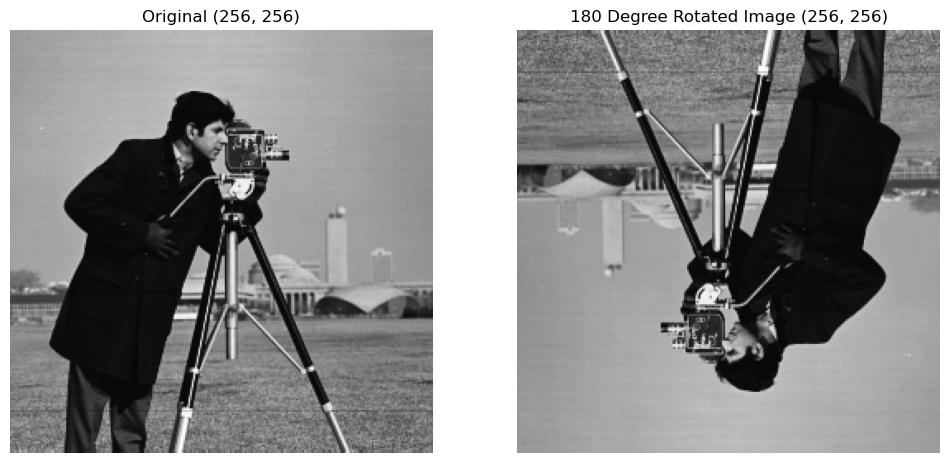

In [ ]:
#1.6.3 Mirror the image horizontally & vertically (180 degree rotation)

# Load the image
image_path = 'DIP3E_Original_Images_CH02/Fig0222(b)(cameraman).tif'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

H, W = img.shape
mirrored_img = np.zeros_like(img)

for i in range(H):
    for j in range(W):
        # Copy pixel from the opposite side of both the column AND the row
        # This performs a full 180-degree rotation
        mirrored_img[i, j] = img[H - 1 - i, W - 1 - j]

show_comparison(img, mirrored_img, "180 Degree Rotated Image")